#### Logical Operations

In [31]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

% matplotlib inline

UsageError: Line magic function `%` not found.


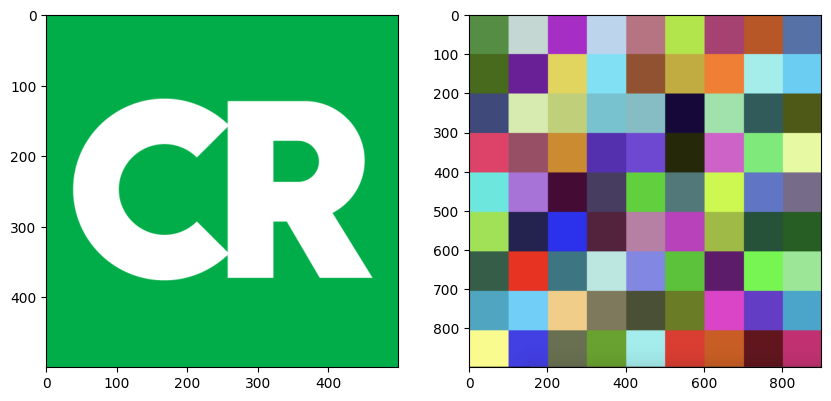

In [32]:
img1 = cv2.imread('data/images/CR_Logo.png', cv2.IMREAD_COLOR)
img2 = cv2.imread('data/images/checkerboard_color.png', cv2.IMREAD_COLOR)

plt.figure(figsize=(10, 10))
plt.subplot(121);plt.imshow(img1[...,::-1]);
plt.subplot(122);plt.imshow(img2[...,::-1]);

In [33]:
img1.shape, img2.shape

((500, 500, 3), (900, 900, 3))

In [34]:
dim = (img1.shape[0], img1.shape[1])
img2 = cv2.resize(img2, dim, interpolation=cv2.INTER_AREA)
img2.shape

(500, 500, 3)

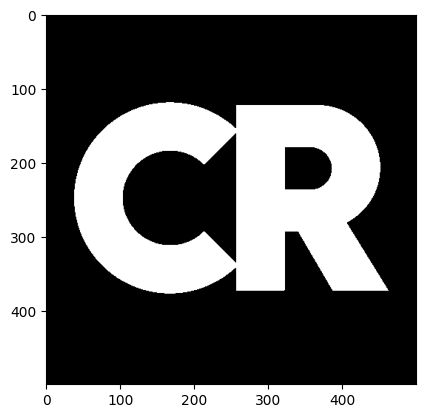

In [35]:
img1_gray = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
_, mask = cv2.threshold(img1_gray, 127, 255, cv2.THRESH_BINARY)

plt.imshow(mask, cmap="gray")

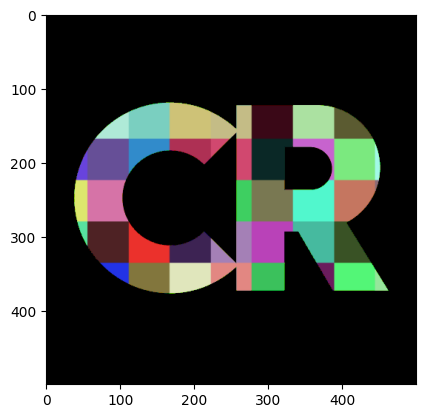

In [36]:
img_bg = cv2.bitwise_and(img1, img2, mask=mask)
plt.imshow(img_bg)

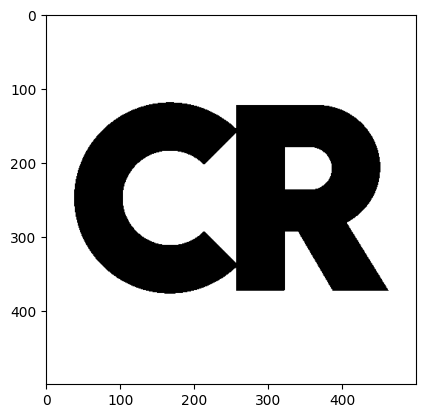

In [37]:
invMask = cv2.bitwise_not(mask)
plt.imshow(invMask, cmap="gray")

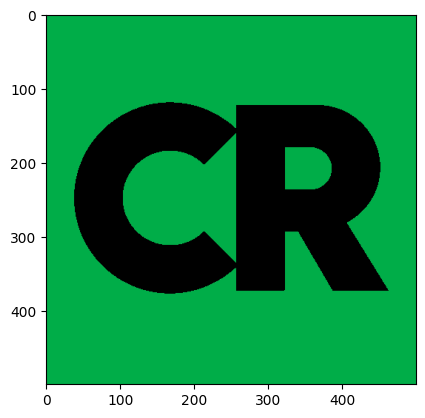

In [38]:
img_foreground = cv2.bitwise_and(img1, img1, mask=invMask)
plt.imshow(img_foreground[...,::-1])


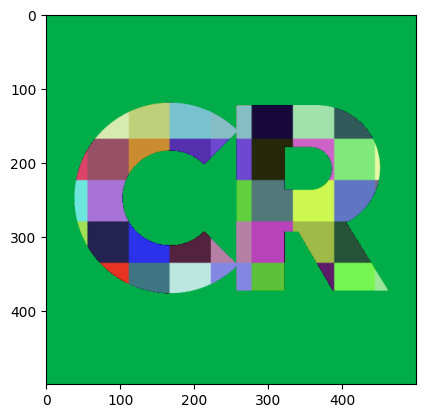

In [40]:
res = cv2.bitwise_or(img_foreground, img_bg, mask=None)
plt.imshow(res[...,::-1])

#### Exercise 2

In [43]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

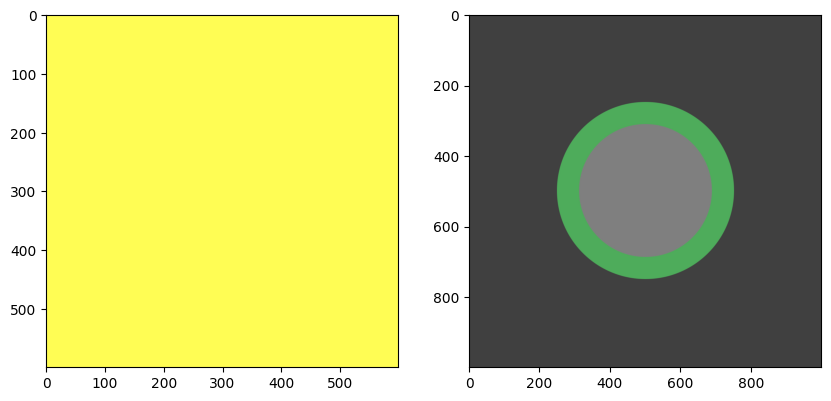

In [46]:
img_yellow_square = cv2.imread('data/images/yellow_square.png', cv2.IMREAD_COLOR)
img_green_circle = cv2.imread('data/images/green_circle.png', cv2.IMREAD_COLOR)

plt.figure(figsize=(10, 10))
plt.subplot(121);plt.imshow(img_yellow_square[...,::-1])
plt.subplot(122);plt.imshow(img_green_circle[...,::-1])

(600, 600, 3) (600, 600, 3)


(600, 600, 3)

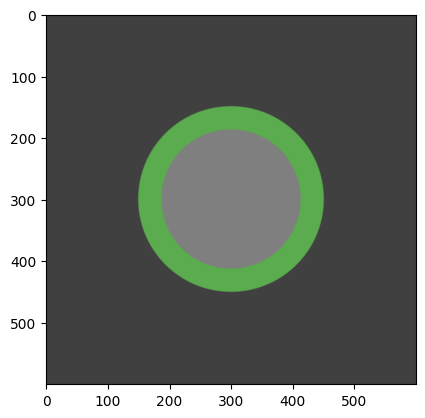

In [51]:
print(img_yellow_square.shape, img_green_circle.shape)

dsize = (img_yellow_square.shape[0], img_yellow_square.shape[1])
img_green_circle = cv2.resize(img_green_circle, dsize, interpolation=cv2.INTER_AREA)
plt.imshow(img_green_circle)
img_green_circle.shape

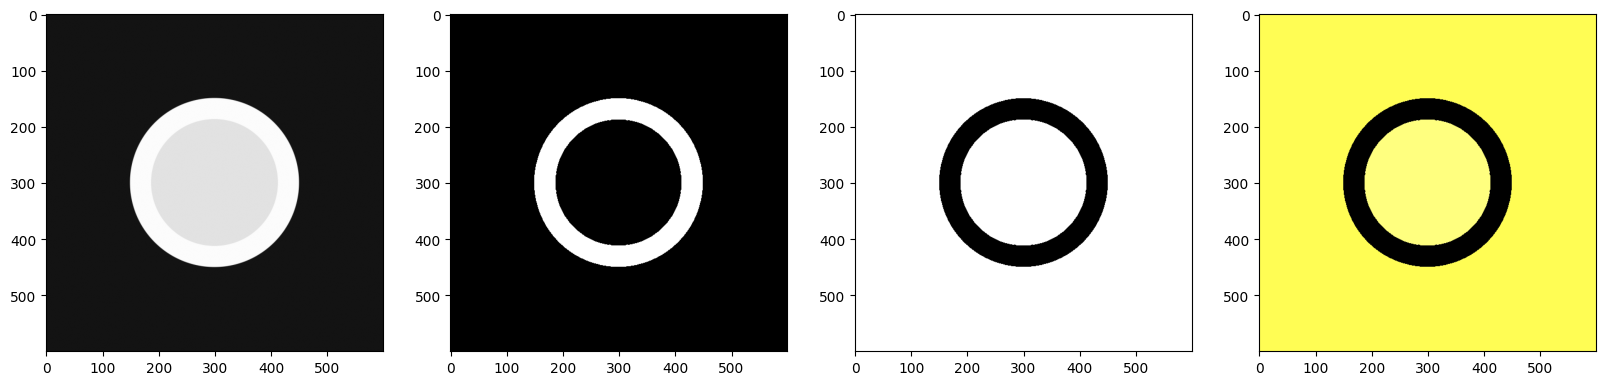

In [76]:
# convert green circle to grayscale and threshold
img_gc = cv2.cvtColor(img_green_circle, cv2.COLOR_BGR2GRAY)
_, img_thresh = cv2.threshold(img_gc, 127, 255, cv2.THRESH_BINARY)

img_thresh_inv = cv2.bitwise_not(img_thresh)

combined = cv2.bitwise_or(img_yellow_square, img_green_circle, mask = img_thresh_inv)

plt.figure(figsize=(20, 10))
plt.subplot(141);plt.imshow(img_gc, cmap="gray")
plt.subplot(142);plt.imshow(img_thresh, cmap="gray")
plt.subplot(143);plt.imshow(img_thresh_inv, cmap="gray")
plt.subplot(144);plt.imshow(combined[...,::-1], cmap="gray")

#### Alpha Channel

In [89]:
import cv2
import matplotlib.pyplot as plt

%matplotlib inline

(2436, 2623, 4)


Text(0.5, 1.0, 'Alpha')

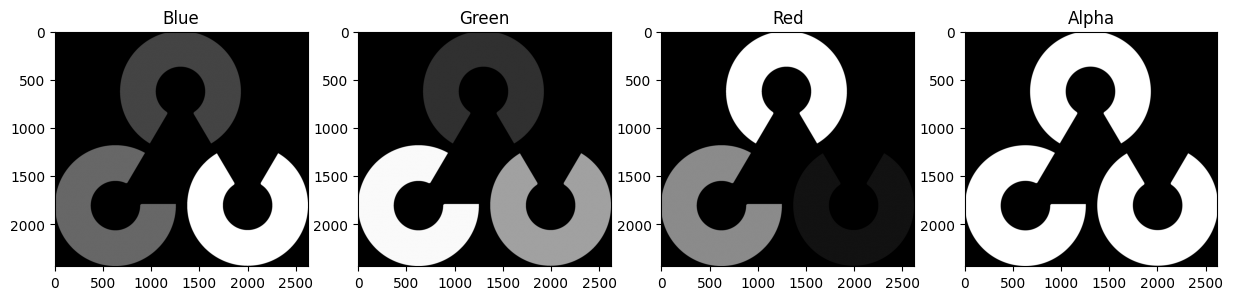

In [93]:
img = cv2.imread('data/images/opencv_logo.png', cv2.IMREAD_UNCHANGED)

print(img.shape)

b, g, r, a = cv2.split(img)

plt.figure(figsize = (15,15))
plt.subplot(141); plt.imshow(b, cmap="gray"); plt.title('Blue')
plt.subplot(142); plt.imshow(g, cmap="gray"); plt.title('Green')
plt.subplot(143); plt.imshow(r, cmap="gray"); plt.title('Red')
plt.subplot(144); plt.imshow(a, cmap="gray"); plt.title('Alpha')

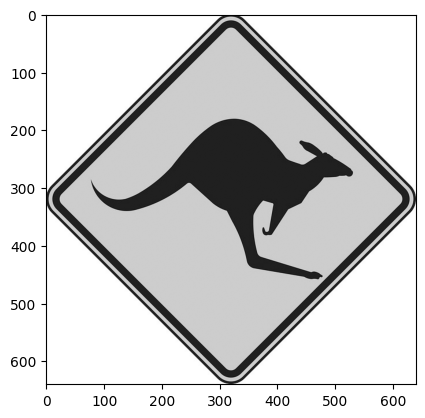

In [95]:
img2 = cv2.imread('data/images/kangaroo.jpg', cv2.IMREAD_COLOR)

img2_gray = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

plt.imshow(img2_gray, cmap="gray")

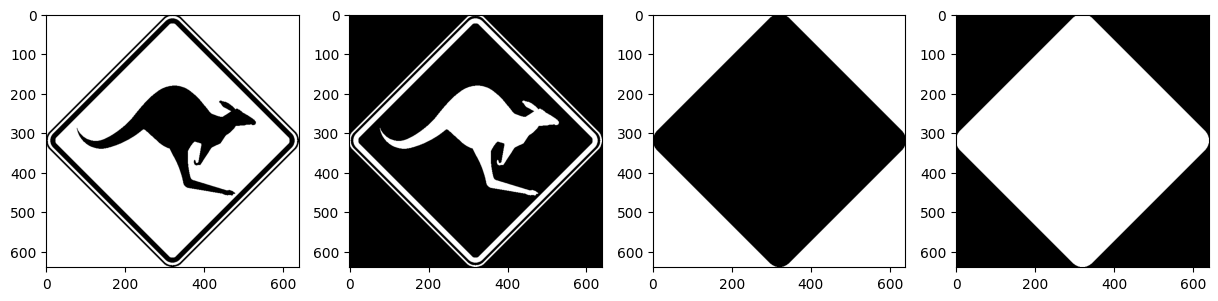

In [107]:
_, dst = cv2.threshold(img2_gray, 127, 255, cv2.THRESH_BINARY)
_, dst1 = cv2.threshold(img2_gray, 230, 255, cv2.THRESH_BINARY)

dst_inv = cv2.bitwise_not(dst)
dst_inv1 = cv2.bitwise_not(dst1)

plt.figure(figsize=(15, 10))
plt.subplot(141);plt.imshow(dst, cmap="gray")
plt.subplot(142);plt.imshow(dst_inv, cmap="gray")
plt.subplot(143);plt.imshow(dst1, cmap="gray")
plt.subplot(144);plt.imshow(dst_inv1, cmap="gray")

In [129]:
# add the alpha channel to the original image and save the image
b, g, r = cv2.split(img2)
mat = [b, g, r, dst_inv1]

finalImage = cv2.merge(mat)

cv2.imwrite('Kangaroo_with_alpha.png', finalImage)


True

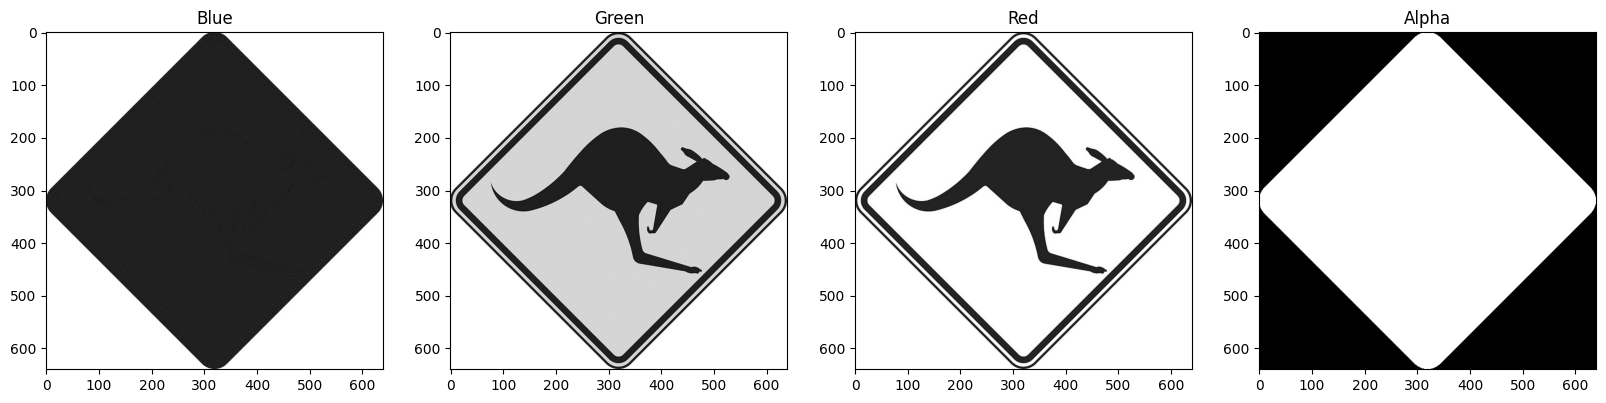

In [136]:
# Actual image in the folder is correct, somehow the its not showing the final image here
img = cv2.imread('data/images/Kangaroo_with_alpha.png', cv2.IMREAD_UNCHANGED)

b, g, r, a = cv2.split(img)

# Display each of the channels.
plt.figure(figsize = (20,15))
plt.subplot(141); plt.imshow(b, cmap="gray"); plt.title('Blue')
plt.subplot(142); plt.imshow(g, cmap="gray"); plt.title('Green')
plt.subplot(143); plt.imshow(r, cmap="gray"); plt.title('Red')
plt.subplot(144); plt.imshow(a, cmap="gray"); plt.title('Alpha');

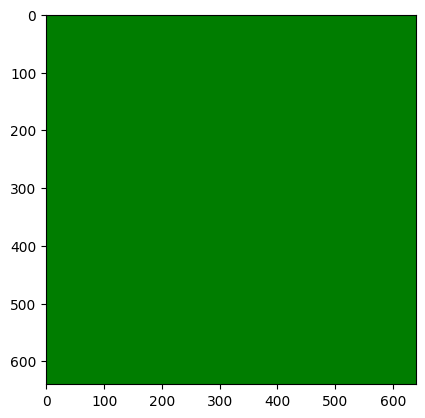

In [118]:
ones = np.ones(dst.shape, dtype="uint8")
ones = ones * 125
zeros = np.zeros(dst.shape, dtype="uint8")
mat = [zeros, ones, zeros]
green_square = cv2.merge(mat)

plt.imshow(green_square[...,::-1])

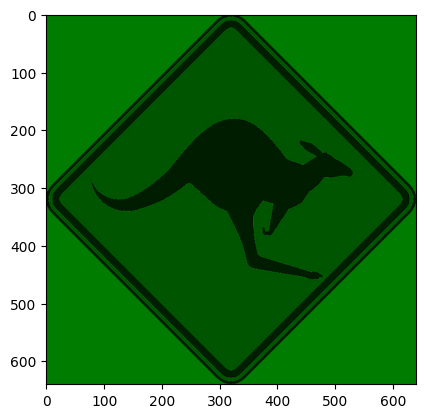

In [128]:
x = cv2.bitwise_and(green_square, img2, dst_inv)
plt.imshow(x[...,::-1])

#### Application 1: Creating Watermarks

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

In [11]:
img = cv2.imread('data/images/leaves.jpg', cv2.IMREAD_UNCHANGED)
logo = cv2.imread('data/images/opencv_logo.png', cv2.IMREAD_UNCHANGED)

print(f'Image size: {img.shape} \nLogo Size: {logo.shape}')

Image size: (730, 1094, 3) 
Logo Size: (2436, 2623, 4)


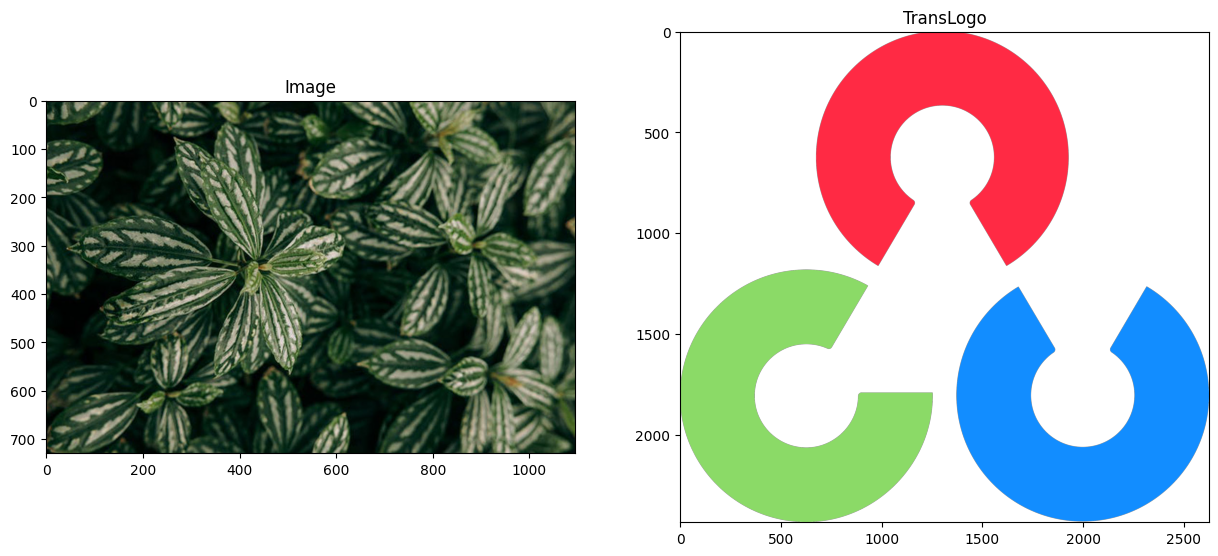

In [12]:
logo = cv2.cvtColor(logo, cv2.COLOR_BGRA2RGBA)

plt.figure(figsize=(15,10))
plt.subplot(121); plt.imshow(img[:, :, ::-1]); plt.title('Image');
plt.subplot(122); plt.imshow(logo);plt.title('TransLogo');

In [13]:
logo_resized = cv2.resize(logo, None, fx=0.1, fy=0.1, interpolation=cv2.INTER_LINEAR)
logo_resized.shape

(244, 262, 4)

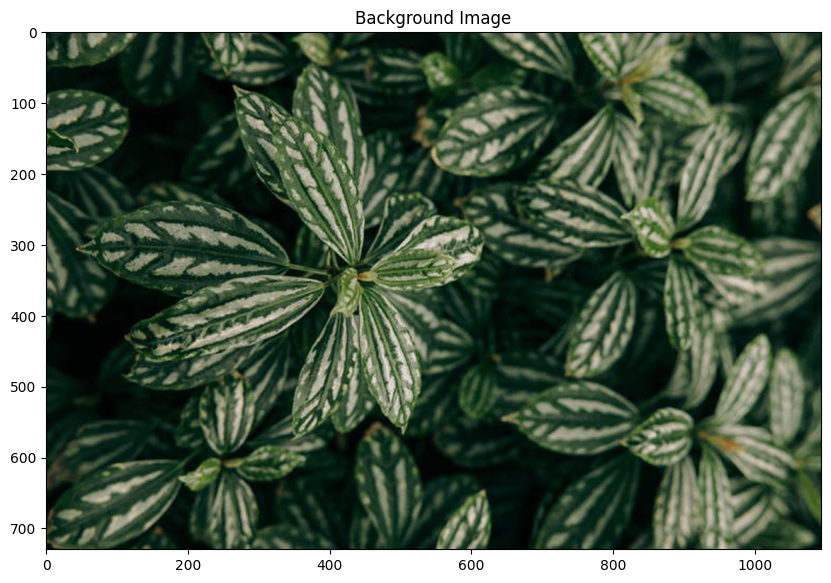

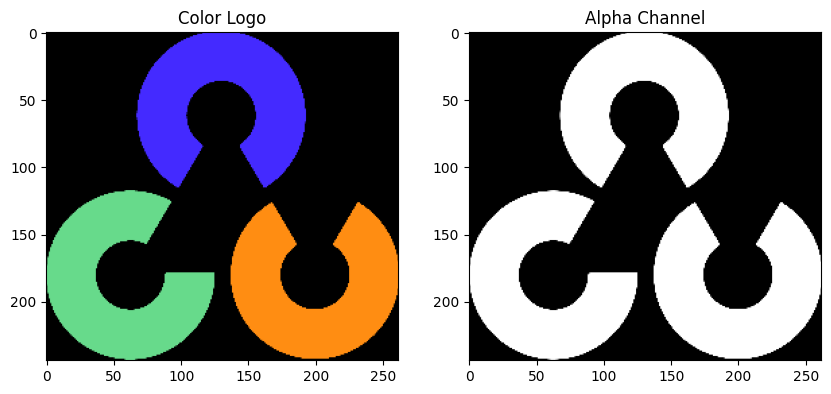

In [14]:
logo_bgr = logo_resized[...,0:3]
logo_alpha = logo_resized[...,3]

plt.figure(figsize = (10, 10))
plt.imshow(img[:, :, ::-1]); plt.title('Background Image');

plt.figure(figsize = (10, 5))
plt.subplot(121); plt.imshow(logo_bgr[:, :, ::-1]);  plt.title('Color Logo');
plt.subplot(122); plt.imshow(logo_alpha, cmap='gray');plt.title('Alpha Channel');

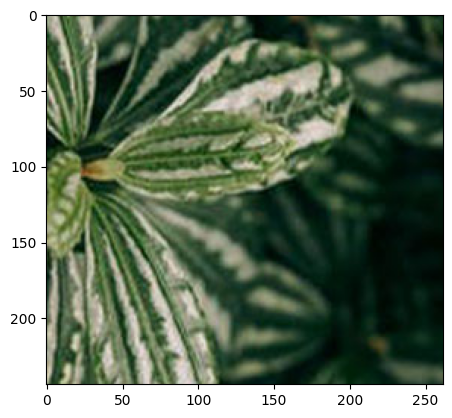

In [18]:
img_w, img_h, _ = img.shape
logo_w, logo_h, _ = logo_resized.shape

# find center to place logo on the background
cx = int(img_w/2)
cy = int(img_h/2)

# top left corner
tlc_x = int(cx - logo_w/2)
tlc_y = int(cy - logo_h/2)

# bottom right corner
brc_x = int(cx + logo_w/2)
brc_y = int(cy + logo_h/2)

# region of interest
roi = img[tlc_x:brc_x, tlc_y:brc_y]

plt.imshow(roi[:,:,::-1])

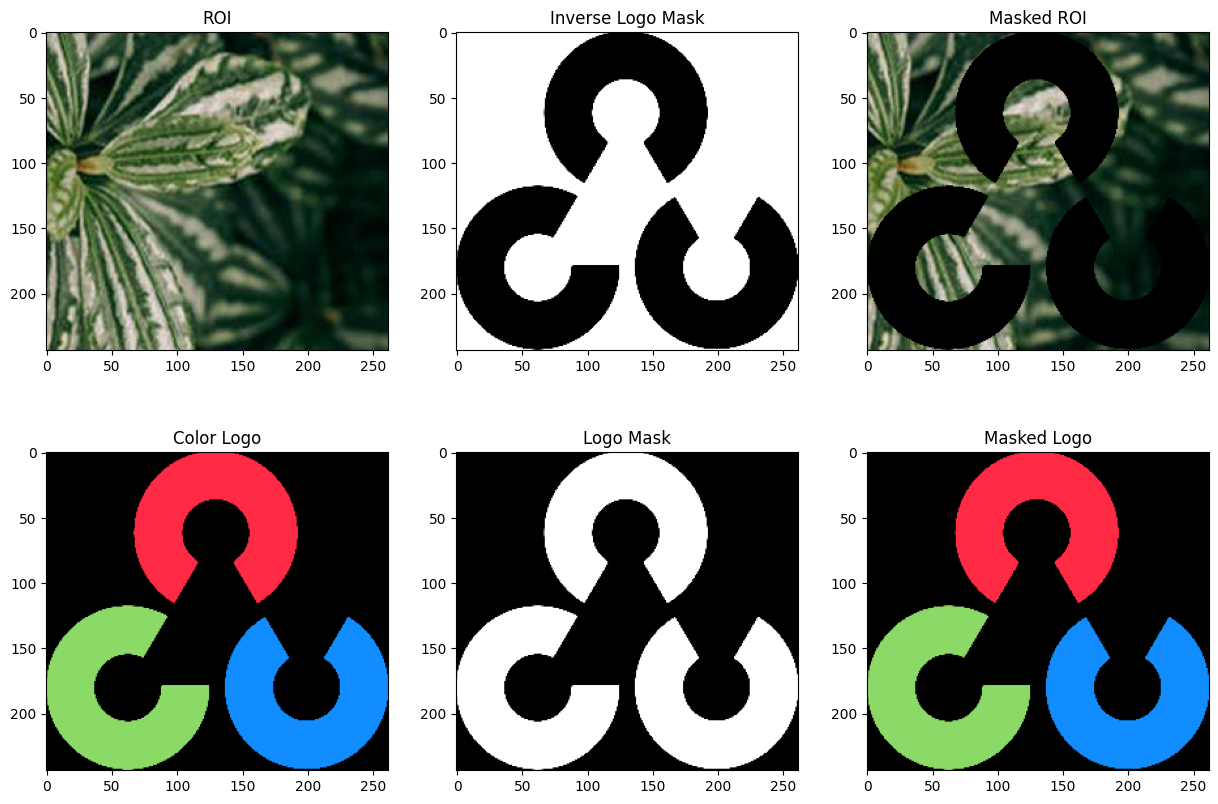

In [21]:
logo_mask = cv2.merge([logo_alpha, logo_alpha, logo_alpha])

logo_mask_inv = cv2.bitwise_not(logo_mask)

masked_roi = cv2.bitwise_and(roi, logo_mask_inv)

masked_logo = cv2.bitwise_and(logo_bgr, logo_mask)

plt.figure(figsize = [15, 10])

plt.subplot(231); plt.imshow(roi[:, :, ::-1]);           plt.title("ROI");
plt.subplot(232); plt.imshow(logo_mask_inv[:, :, ::-1]); plt.title("Inverse Logo Mask");
plt.subplot(233); plt.imshow(masked_roi[:, :, ::-1]);    plt.title("Masked ROI");

plt.subplot(234); plt.imshow(logo_bgr);      plt.title("Color Logo");
plt.subplot(235); plt.imshow(logo_mask[:, :, ::-1]);     plt.title("Logo Mask");
plt.subplot(236); plt.imshow(masked_logo);   plt.title("Masked Logo");

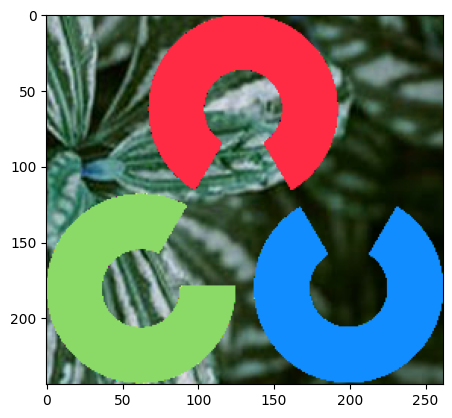

In [22]:
roi_final = cv2.bitwise_or(masked_roi, masked_logo)

plt.imshow(roi_final)

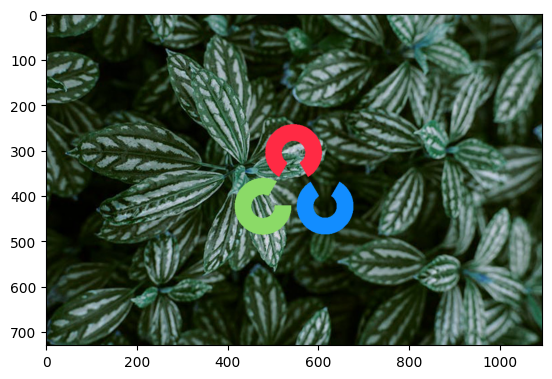

In [25]:
img1 = img.copy()

img1[tlc_x:brc_x, tlc_y: brc_y] = roi_final

plt.imshow(img1)

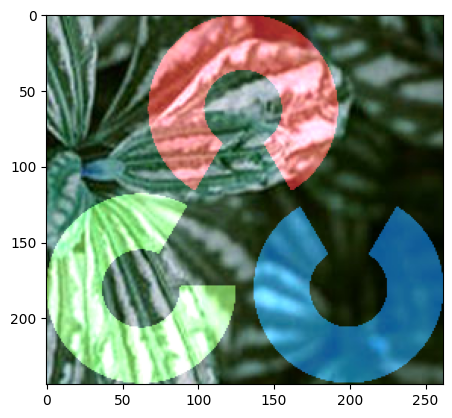

In [ ]:
# addWeighted is used to blend two images together. The function takes in two images, their respective weights, and an optional scalar added to the sum of the weighted images. The formula for the function is: dst = src1*alpha + src2*beta + gamma, where alpha and beta are the weights for the two images, and gamma is the scalar added to the sum.
watermarked = cv2.addWeighted(roi, 1, logo_bgr, 0.6, 0)

plt.imshow(watermarked)

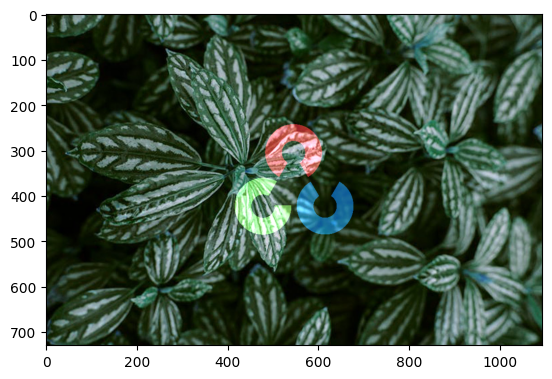

In [29]:
img2 = img.copy()

img2[tlc_x:brc_x, tlc_y:brc_y] = watermarked

plt.imshow(img2)

#### Application 2: Creating A Digital Signature

In [30]:
import cv2
import matplotlib.pyplot as plt

%matplotlib inline

(3024, 4032, 3)


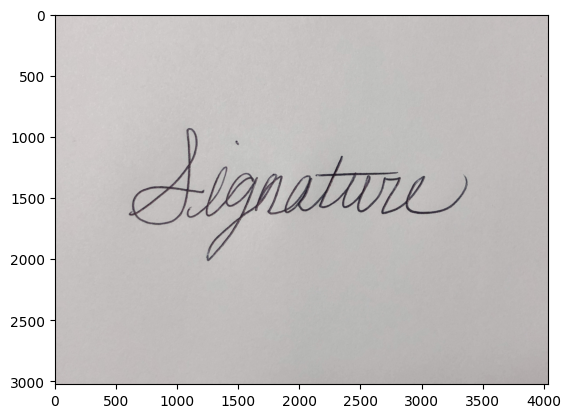

In [31]:
sig_org = cv2.imread('data/images/signature.jpg', cv2.IMREAD_UNCHANGED)

print(sig_org.shape)

plt.imshow(sig_org[...,::-1])

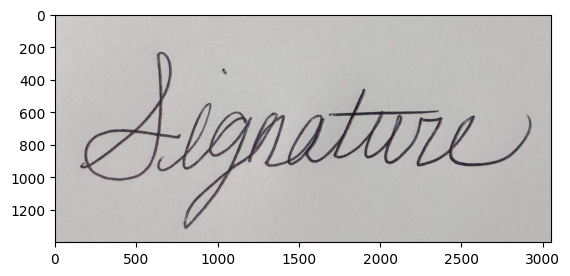

In [32]:
sig = sig_org[700:2100, 450:3500, :]
plt.imshow(sig[...,::-1])

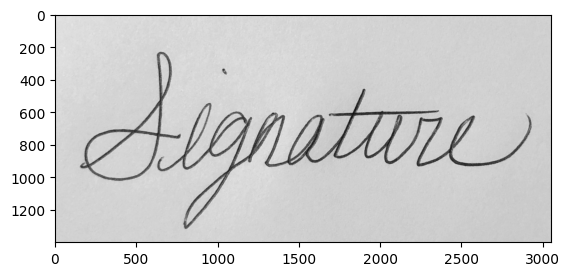

In [33]:
sig_gray = cv2.cvtColor(sig, cv2.COLOR_BGR2GRAY)
plt.imshow(sig_gray, cmap="gray")

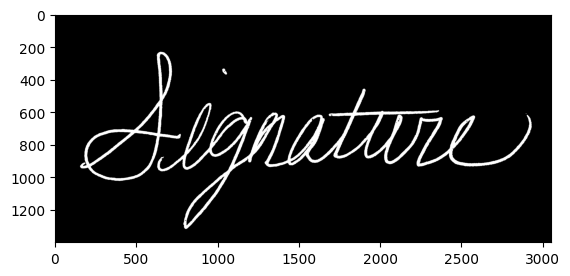

In [36]:
ret, alpha_mask = cv2.threshold(sig_gray, 150, 255, cv2.THRESH_BINARY_INV)
plt.imshow(alpha_mask, cmap="gray")

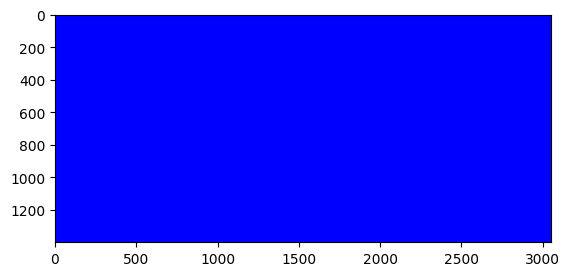

In [37]:
blue_mask = sig.copy()
blue_mask[:, :] = (255, 0, 0)
plt.imshow(blue_mask[...,::-1])

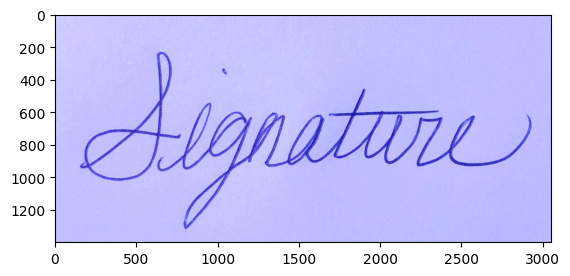

In [38]:
sig_color = cv2.addWeighted(sig, 1, blue_mask, 0.5, 0)
plt.imshow(sig_color[...,::-1])

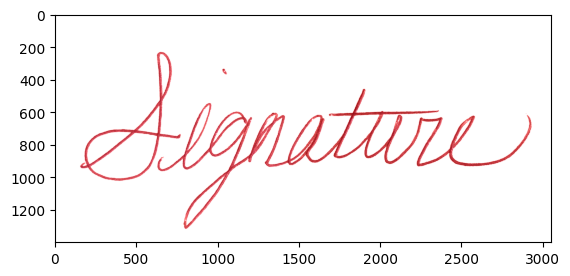

In [41]:
b,g,r = cv2.split(sig_color)
mat = [b, g, r, alpha_mask]
png = cv2.merge(mat)

cv2.imwrite('data/images/signature_with_alpha.png', png)

plt.imshow(png)